   StudentID  GPA  Study Hours
0          1  2.5           10
1          2  3.0           15
2          3  3.2           18
3          4  3.8           35
4          5  2.9           12
5          6  1.8            6
6          7  2.2            8
7          8  3.9           40
8          9  3.5           32
9         10  1.6            5


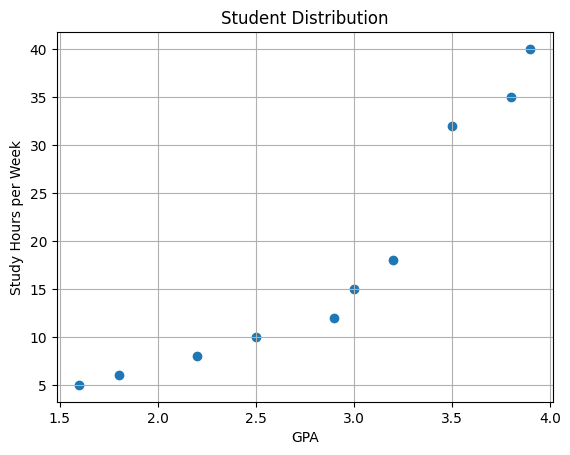

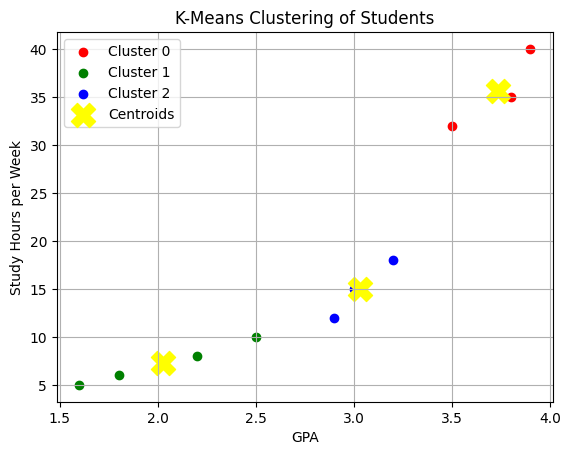

New student belongs to cluster: 2


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
data = {
'StudentID': [1,2,3,4,5,6,7,8,9,10],
'GPA': [2.5, 3.0, 3.2, 3.8, 2.9, 1.8, 2.2, 3.9, 3.5, 1.6],
'Study Hours': [10, 15, 18, 35, 12, 6, 8, 40, 32, 5]
}
df = pd.DataFrame(data)
print(df)
X = df[['GPA', 'Study Hours']]
plt.scatter(X['GPA'], X['Study Hours'])
plt.xlabel('GPA')
plt.ylabel('Study Hours per Week')
plt.title('Student Distribution')
plt.grid(True)
plt.show()
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.scatter(df[df['Cluster'] == i]['GPA'],
                df[df['Cluster'] == i]['Study Hours'],
                color=colors[i], label=f'Cluster {i}')
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c='yellow', s=300, marker='X', label='Centroids')
plt.xlabel('GPA')
plt.ylabel('Study Hours per Week')
plt.title('K-Means Clustering of Students')
plt.legend()
plt.grid(True)
plt.show()
new_student_data = {'GPA': [3.1], 'Study Hours': [20]}
new_student_df = pd.DataFrame(new_student_data, columns=X.columns)
predicted_cluster = kmeans.predict(new_student_df)
print('New student belongs to cluster:', predicted_cluster[0])